# Day 2 Workbook: Penguins Visualization and Storytelling

This workbook continues from Day 1. Yesterday, the main goal was to load data, inspect it, clean basic issues, filter rows, group values, and write short conclusions.

Today, the goal is to turn data into readable charts and short visual stories.

Dataset: `penguins.csv`

Estimated time: 3 to 5 academic hours.


## Learning Outcomes

By the end of this notebook, you should be able to:

- load a second CSV dataset in Google Colab
- inspect rows, columns, data types, and missing values before charting
- explain what the Penguins dataset contains
- choose a reasonable chart type for a practical question
- create basic charts with Matplotlib
- create grouped statistical charts with Seaborn
- create simple interactive charts with Plotly
- improve chart titles, labels, figure size, and legends
- write short, careful interpretations of visual patterns
- assemble a short visual mini report with 2 to 3 charts


## How to Use This Workbook

Run the notebook from top to bottom.

In Google Colab, you can run one cell at a time with the play button on the left side of a cell. You can also use **Runtime > Run all**.

Day 1 reminder:

- Markdown cells explain the analysis.
- Code cells do the work.
- Output appears below code cells.
- Variables remember values created by earlier cells.
- If something looks strange, first check whether the cells above it have been run.

This notebook includes complete working code. In guided practice sections, you can change small parts of the code after you have seen it run once.


## Setup

We use the same core libraries as Day 1, plus two visualization libraries.

- `pandas` loads and summarizes tables.
- `matplotlib.pyplot` creates basic charts.
- `seaborn` creates clear statistical charts with less code.
- `plotly.express` creates interactive charts.

Colab usually already includes these libraries, so we do not need installation cells.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.max_open_warning"] = 50

try:
    import plotly.express as px
    import plotly.io as pio

    try:
        pio.renderers.default = "colab"
    except Exception:
        pass

    PLOTLY_AVAILABLE = True
    print("Plotly is available.")
except ImportError:
    px = None
    PLOTLY_AVAILABLE = False
    print("Plotly is not available in this environment. The Plotly sections will print a note instead.")


Plotly is available.


In [3]:
# When starting  a fresh notebook I also like to print out the following:
# current datetime
# python version
# location of Python executable
# these are all optional but show roughly what we are running and when
from datetime import datetime
print(f"Today is {datetime.now()}")
import sys
print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")

Today is 2026-05-12 11:07:05.214857
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Python executable: /usr/bin/python3


## Load the Penguins Dataset

The data file is stored in the course repository as `data/penguins.csv`.

The loading cell below tries local paths first. This is helpful when the notebook is run from the repository. If the local file is not found, it loads the CSV from a stable raw GitHub URL, which is helpful in Google Colab.

The dataset uses `NA` for some missing values, so we tell Pandas to treat `NA` as missing data.


In [4]:
from pathlib import Path

PENGUINS_URL = "https://raw.githubusercontent.com/ValRCS/RTU_Python_Data_Analysis_Visualization_May_2026/main/data/penguins.csv"

local_paths = [
    Path("../../data/penguins.csv"),  # when the notebook runs from notebooks/day_2/
    Path("data/penguins.csv"),       # when the notebook runs from the repository root
]

for local_path in local_paths:
    if local_path.exists():
        penguins = pd.read_csv(local_path, na_values="NA")
        print(f"Loaded local file: {local_path}")
        break
else:
    penguins = pd.read_csv(PENGUINS_URL, na_values="NA")
    print("Loaded remote file from GitHub.")

penguins.head()


Loaded remote file from GitHub.


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [5]:
# minimal version to load this dataset by creating a new variable
also_penguins = pd.read_csv("https://raw.githubusercontent.com/ValRCS/RTU_Python_Data_Analysis_Visualization_May_2026/main/data/penguins.csv")
also_penguins.head() # let's take a look

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [6]:
# what is the shape of penguins?
penguins.shape

(344, 8)

## What Is the Penguins Dataset?

The Penguins dataset contains observations of penguins from the Palmer Archipelago in Antarctica. Each row is one observed penguin. The columns describe the penguin species, island, body measurements, sex, and observation year.

This dataset is useful for learning visualization because it contains:

- categories, such as `species`, `island`, and `sex`
- numeric measurements, such as `body_mass_g` and `flipper_length_mm`
- natural group comparisons, such as comparing species
- relationships between measurements, such as flipper length and body mass

Plain-language measurement guide:

| Column | Meaning |
| --- | --- |
| `species` | Penguin species: Adelie, Chinstrap, or Gentoo |
| `island` | Island where the penguin was observed |
| `bill_length_mm` | Length of the penguin's bill in millimeters |
| `bill_depth_mm` | Depth of the penguin's bill in millimeters |
| `flipper_length_mm` | Length of the penguin's flipper in millimeters |
| `body_mass_g` | Body mass in grams |
| `sex` | Recorded sex of the penguin |
| `year` | Observation year |

We will use this dataset to practice choosing charts, making charts readable, and writing careful conclusions.


## Subchapter 1: Meet the Dataset and Reuse Day 1 Inspection Skills

### Goal

Before making charts, we inspect the dataset. This is the same habit from Day 1.

In Excel, this is similar to opening a worksheet, checking the header row, looking for blanks, and checking whether columns contain numbers or labels.


### Instructor Demonstration

Start with the first few rows. This confirms that the data loaded correctly and gives us a quick sense of what each row contains.


In [7]:
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Each row represents one observed penguin. Each column stores one piece of information about that penguin.

Next, check the number of rows and columns.


In [8]:
row_count, column_count = penguins.shape # I unpack shape into two new variables

print("Rows:", row_count)
print("Columns:", column_count)


Rows: 344
Columns: 8


Now check column names. Column names matter because we must spell them exactly in code.


In [9]:
penguins.columns


Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

`info()` gives a compact overview of data types and non-missing values. This is one of the best first checks before charting.


In [10]:
penguins.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


Numeric columns can be summarized with `describe()`.

This gives counts, averages, minimums, maximums, and quartiles. You do not need to memorize every statistic. For now, focus on whether the numbers look reasonable.


In [11]:
penguins.describe() # again describe by default gives us numeric(int and float) column summary stats


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


Categorical columns contain labels or groups. We can inspect them separately.


In [12]:
penguins[["species", "island", "sex"]].describe()


,species,island,sex
count,344,344,333
unique,3,3,2
top,Adelie,Biscoe,male
freq,152,168,168


In [13]:
# let's do value counts for the categorical columns
penguins["species"].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [14]:
# again let's do value counts for islands
penguins["island"].value_counts()

,count
island,
Biscoe,168
Dream,124
Torgersen,52


In [15]:
# and now sex value counts
penguins["sex"].value_counts()

,count
sex,
male,168
female,165


Missing values are important for charts. A missing measurement may cause a point, bar, or summary to be skipped.


In [16]:
missing_values = penguins.isna().sum().to_frame("missing_rows")
missing_values


,missing_rows
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


Create a small guide for column types. This helps us choose chart types later.


In [17]:
column_guide = pd.DataFrame({
    "column": [
        "species",
        "island",
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
        "sex",
        "year",
    ],
    "plain_language_type": [
        "category",
        "category",
        "numeric measurement",
        "numeric measurement",
        "numeric measurement",
        "numeric measurement",
        "category",
        "year label",
    ],
})

column_guide


,column,plain_language_type
0,species,category
1,island,category
2,bill_length_mm,numeric measurement
3,bill_depth_mm,numeric measurement
4,flipper_length_mm,numeric measurement
5,body_mass_g,numeric measurement
6,sex,category
7,year,year label


For most measurement charts, we will use a cleaned version that removes rows with missing body measurements.

This does not change the original `penguins` table. It creates a new table called `penguins_clean`.


In [20]:
measurement_columns = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

# so we create a new penguins_clean dataframe by dropping rows where any of the measurement columns have missing values and then creating a copy
# note copy() is important otherwise we would get a view (virtual alias) to existing table
penguins_clean = penguins.dropna(subset=measurement_columns).copy() # without .copy() we would be affecting existing dataframe from penguins_clean

print("Original rows:", len(penguins))
print("Rows with complete body measurements:", len(penguins_clean))
# how many rows were dropped
print("Rows dropped:", len(penguins) - len(penguins_clean))


Original rows: 344
Rows with complete body measurements: 342
Rows dropped: 2


### Guided Practice

Run the next cell, then read the output.

This is the same idea as Day 1 category counting. It helps us understand the groups before charting them.


In [21]:
penguins["species"].value_counts()


,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [22]:
penguins["island"].value_counts()


,count
island,
Biscoe,168
Dream,124
Torgersen,52


### Check Your Understanding

Answer in plain language:

1. Which columns are categories?
2. Which columns are numeric measurements?
3. Which columns have missing values?
4. Why might missing values matter before making a chart?


### Independent Mini Task

Display the first 10 rows. Then write one sentence below the output:

> Each row in this dataset represents ...


In [23]:
penguins.head(10)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007


### Interpretation

At this point we know:

- the dataset has 344 rows and 8 columns
- the main groups are species and island
- the main measurements describe bill size, flipper length, and body mass
- some measurement values are missing, so we should be careful when charting


## Subchapter 2: Choosing the Right Chart Type

### Goal

A good chart starts with a good question.

Beginners often ask, "Which chart should I use?" A more useful first question is, "What am I trying to compare, count, or explain?"


### Chart Choice Guide

| Analytical question | Column types | Good chart choices | Penguin example |
| --- | --- | --- | --- |
| How many are in each group? | One category | Bar chart | Count penguins by `species` |
| How are numeric values distributed? | One numeric column | Histogram | Distribution of `body_mass_g` |
| How do groups compare? | Category plus numeric column | Box plot or grouped bar chart | Body mass by `species` |
| Are two measurements related? | Two numeric columns | Scatter plot | Flipper length vs body mass |
| How can we explore details interactively? | Simple comparison | Plotly chart | Hover over a scatter plot by species |

Practical tips:

- Start with the question, not the chart.
- Use bar charts for counts and category comparisons.
- Use histograms for numeric distributions.
- Use box plots when comparing spread across groups.
- Use scatter plots for relationships between two numeric measurements.
- Use color only when it represents useful information.
- Give every chart a clear title and axis labels.
- Avoid 3D charts for this course.
- Be careful with pie charts because they are often hard to compare accurately.


### Instructor Demonstration: Count a Category

First, count how many penguins are in each species.


In [24]:
species_counts = (
    penguins["species"]
    .value_counts()
    .rename_axis("species")
    .reset_index(name="count")
)

species_counts
# again here I could save species_count to csv or excel for further work


,species,count
0,Adelie,152
1,Gentoo,124
2,Chinstrap,68


A count table is useful, but a bar chart can make the comparison easier to see.


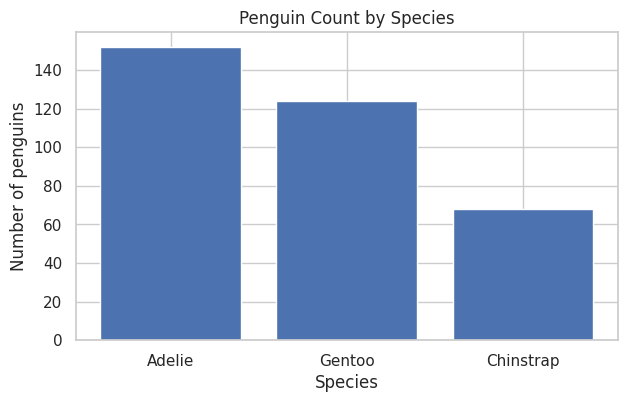

In [25]:
# we will be using matplotlib library
# official documentation is at:
plt.figure(figsize=(7, 4))
# so x axis will be species
# and y axis will be count column
# we want each bar to display values (count)
plt.bar(species_counts["species"], species_counts["count"])


plt.title("Penguin Count by Species")
plt.xlabel("Species")
plt.ylabel("Number of penguins")
plt.show()


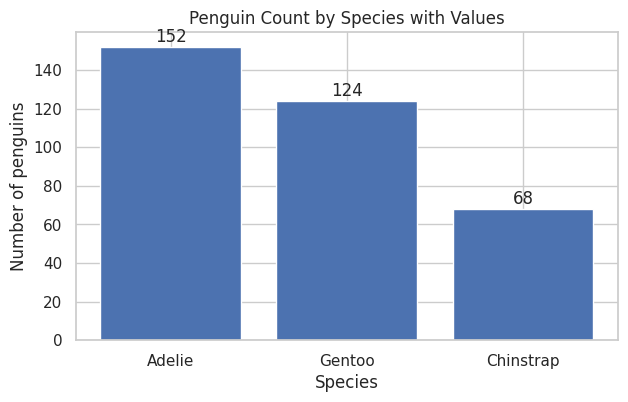

In [35]:
plt.figure(figsize=(7, 4))
bars = plt.bar(species_counts["species"], species_counts["count"])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.title("Penguin Count by Species with Values")
plt.xlabel("Species")
plt.ylabel("Number of penguins")
plt.show()

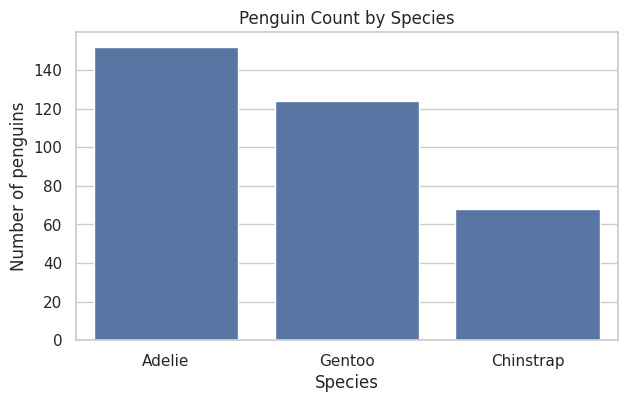

In [28]:
# let's show seaborn version of species_count
# show labels on bars
plt.figure(figsize=(7, 4))
sns.barplot(data=species_counts, x="species", y="count")
plt.title("Penguin Count by Species")
plt.xlabel("Species")
plt.ylabel("Number of penguins")
plt.show()

In [31]:
# let's show plotly example of species_counts
# show labels on bars

fig = px.bar(data_frame=species_counts, x="species", y="count")
# show values on bars
fig.update_traces(text=species_counts["count"], textposition="outside")
fig.show()


Now count another category: island.


In [32]:
island_counts = (
    penguins["island"]
    .value_counts()
    .rename_axis("island")
    .reset_index(name="count")
)

island_counts


,island,count
0,Biscoe,168
1,Dream,124
2,Torgersen,52


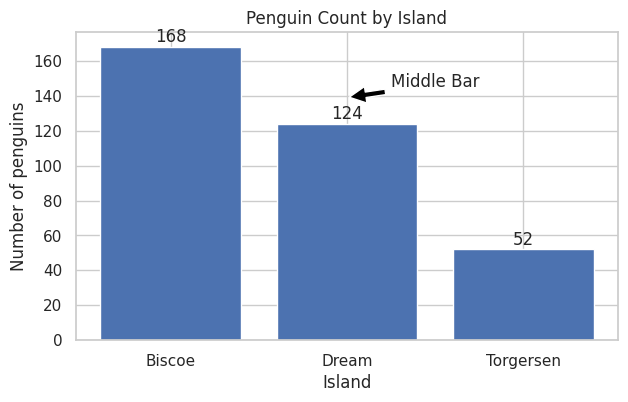

In [41]:
plt.figure(figsize=(7, 4))
bars = plt.bar(island_counts["island"], island_counts["count"])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

# Add an arrow pointing to the middle bar (Dream island)
# The x-coordinate for 'Dream' is 1 (index in the list of islands)
# The y-coordinate for 'Dream' is 124 (its count)
plt.annotate(
    'Middle Bar',
    xy=(1, island_counts.loc[island_counts['island'] == 'Dream', 'count'].iloc[0]+15), # Point at the top of the 'Dream' bar
    xytext=(1.5, 145), # Text position, slightly to the right and above
    arrowprops=dict(facecolor='black', shrink=0.05),
    ha='center'
)

plt.title("Penguin Count by Island")
plt.xlabel("Island")
plt.ylabel("Number of penguins")
plt.show()

### Instructor Demonstration: Show a Numeric Distribution

For one numeric column, a histogram is usually a good first chart. It shows how values are spread across ranges.


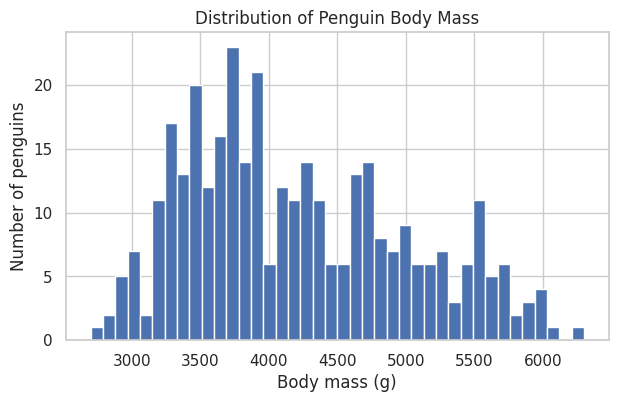

In [43]:
plt.figure(figsize=(7, 4))
plt.hist(penguins_clean["body_mass_g"], bins=40)
plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body mass (g)")
plt.ylabel("Number of penguins")
plt.show()


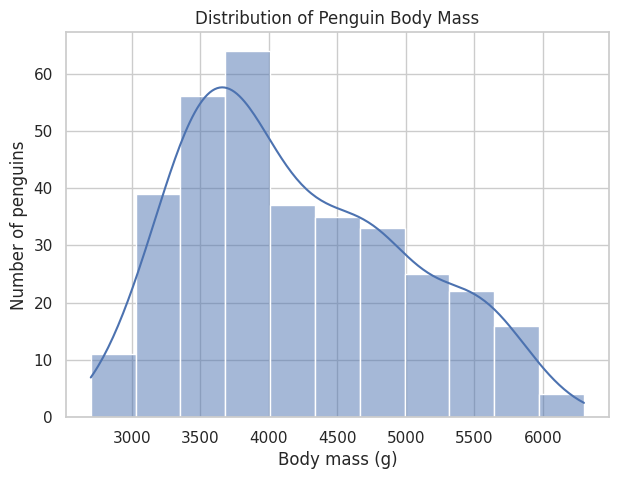

In [46]:
# let's use seaborn to show both histogram and KDE
plt.figure(figsize=(7, 5)) # set size of our figure
# in above 7 and 5 are inches , default is 100 dots per inch
# so 700 x 500
# there is an option to use dots as well
# so we supply as data our dataframe
# our x should be numeric column that exists - here "body_mass_g"
# extra flag we set kde to be True - so kernel density estimator
sns.histplot(data=penguins_clean, x="body_mass_g", kde=True)
plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body mass (g)")
plt.ylabel("Number of penguins")
# i can save this plot here
# before saving I could change the size of the plot
# say 1920x1080
plt.savefig("body_mass_hist.png") # i could use .pdf or jpg as well
plt.show()

In [50]:
# again I could download the file from google colab here
from google.colab import files
files.download("body_mass_hist.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Guided Practice

The next chart repeats the histogram pattern with a different numeric column.

After running it once, try changing `flipper_length_mm` to `bill_length_mm`.


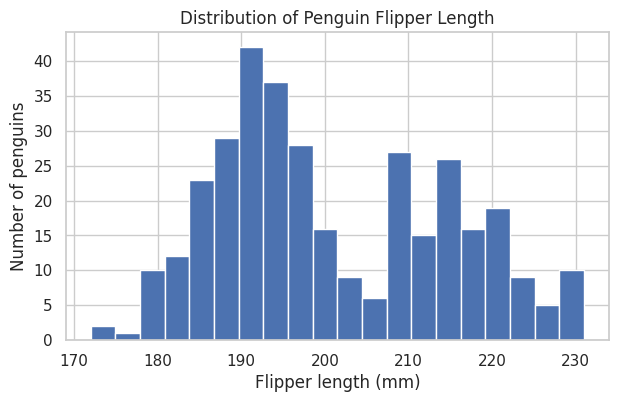

In [52]:
plt.figure(figsize=(7, 4))
plt.hist(penguins_clean["flipper_length_mm"], bins=20)
plt.title("Distribution of Penguin Flipper Length")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Number of penguins")
plt.show()


In [53]:
# columns
penguins_clean.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

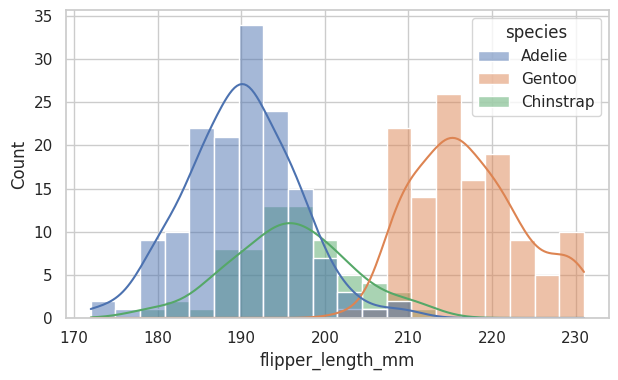

In [55]:
# let's use seaborn to provide historgram for flipper_length_mm by species
plt.figure(figsize=(7, 4))
sns.histplot(data=penguins_clean, x="flipper_length_mm", hue="species", bins=20, kde=True)

<Axes: xlabel='body_mass_g', ylabel='Count'>

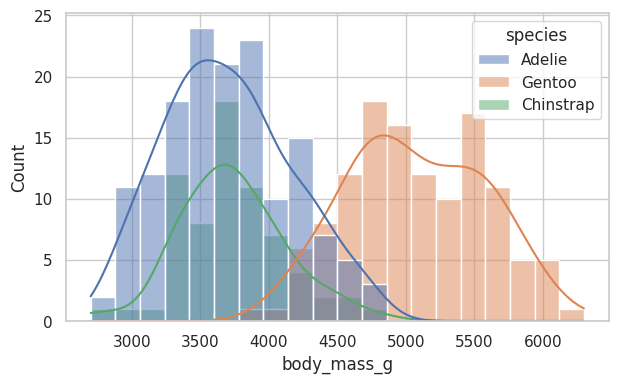

In [56]:
# let's do the same histogram by body mass in g again colored by species
plt.figure(figsize=(7, 4))
sns.histplot(data=penguins_clean, x="body_mass_g", hue="species", bins=20, kde=True)

### Check Your Understanding

1. Why is a bar chart appropriate for `species`?
2. Why is a histogram appropriate for `body_mass_g`?
3. Would a histogram be appropriate for `island`? Why or why not?
4. What should every chart title help the reader understand?


In [61]:
# let's use plotly to create histograms of flipper_length_mm with kde colored by species
fig = px.histogram(data_frame=penguins_clean,
                   x="flipper_length_mm",
                   color="species",
                  #  marginal="violin",
                   marginal="box",

                   hover_data=penguins_clean.columns
                   )
fig.show()

### Independent Mini Task

Create a bar chart of penguin counts by island. The working version is below. Change the title to make it more specific.


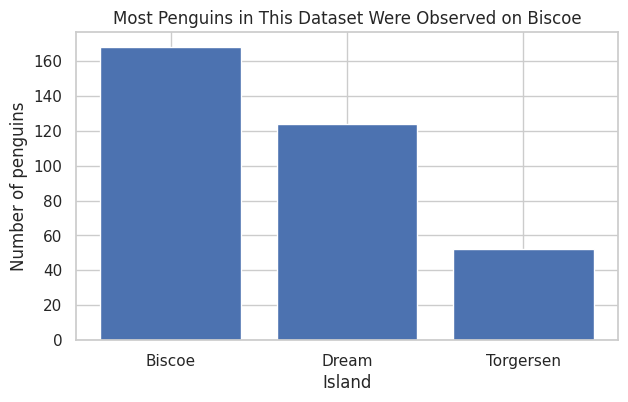

In [57]:
plt.figure(figsize=(7, 4))
plt.bar(island_counts["island"], island_counts["count"])
plt.title("Most Penguins in This Dataset Were Observed on Biscoe")
plt.xlabel("Island")
plt.ylabel("Number of penguins")
plt.show()


### Common Mistake

A common mistake is choosing a chart because it looks interesting, not because it answers the question.

For example, a scatter plot is not useful for counting species because a scatter plot needs numeric x and y values. A bar chart is simpler and clearer for counts.


### Interpretation

For category counts, use a count table and a bar chart.

For one numeric measurement, use a histogram to see the spread of values.


## Subchapter 3: Matplotlib Foundations

### Goal

Matplotlib is the base plotting library used by many Python visualization tools.

The code can look a little more manual than Seaborn or Plotly, but it helps you understand the parts of a chart:

- figure size
- chart type
- title
- x-axis label
- y-axis label
- visible output


### Instructor Demonstration: Bar Chart

This is the same species count chart, written with Matplotlib functions.


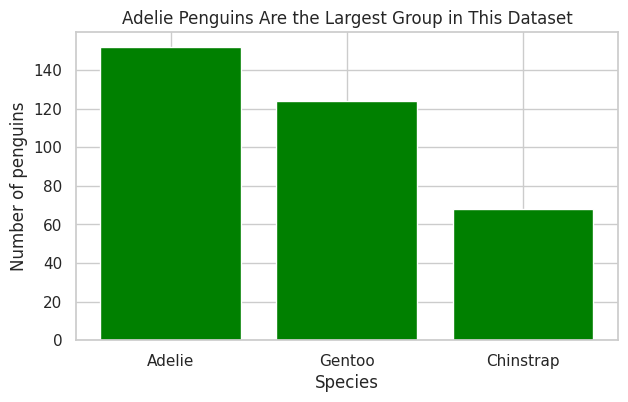

In [67]:
# set figure custom figure size first - optional
plt.figure(figsize=(7, 4))
# what are we plotting and how, here bar chart and we pass x and y values
plt.bar(species_counts["species"], species_counts["count"], color="green")
# optional - but highly recommended title and x and y labels
plt.title("Adelie Penguins Are the Largest Group in This Dataset")
plt.xlabel("Species")
plt.ylabel("Number of penguins")
# explicit show
# I could save the file or show or both
plt.show()


The title now says something more useful than only naming the chart. It points the reader toward the main observation.


### Instructor Demonstration: Histogram

The `bins` argument controls how many ranges the histogram uses. More bins show more detail. Fewer bins show a smoother summary.


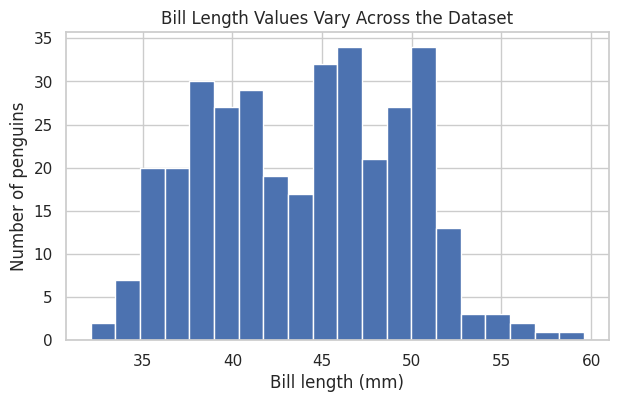

In [68]:
plt.figure(figsize=(7, 4))
plt.hist(penguins_clean["bill_length_mm"], bins=20)
plt.title("Bill Length Values Vary Across the Dataset")
plt.xlabel("Bill length (mm)")
plt.ylabel("Number of penguins")
plt.show()


Try a different number of bins to see how the chart changes.


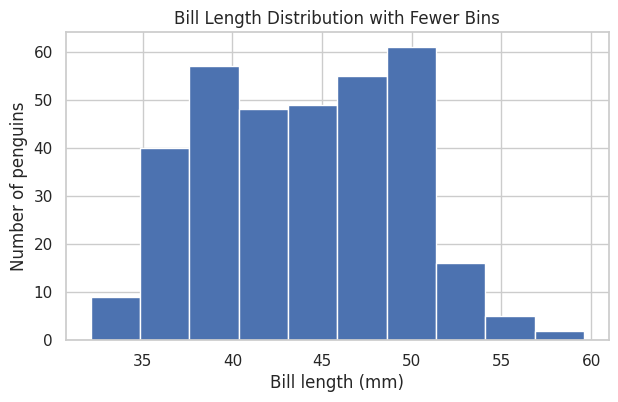

In [69]:
plt.figure(figsize=(7, 4))
plt.hist(penguins_clean["bill_length_mm"], bins=10)
plt.title("Bill Length Distribution with Fewer Bins")
plt.xlabel("Bill length (mm)")
plt.ylabel("Number of penguins")
plt.show()


In [71]:
penguins_clean.sample(7)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
140,Adelie,Dream,40.2,17.1,193.0,3400.0,female,2009
168,Gentoo,Biscoe,42.0,13.5,210.0,4150.0,female,2007
276,Chinstrap,Dream,46.5,17.9,192.0,3500.0,female,2007
243,Gentoo,Biscoe,52.2,17.1,228.0,5400.0,male,2009
234,Gentoo,Biscoe,47.4,14.6,212.0,4725.0,female,2009
171,Gentoo,Biscoe,48.7,15.1,222.0,5350.0,male,2007
161,Gentoo,Biscoe,46.8,15.4,215.0,5150.0,male,2007


Text(0.5, 1.0, 'Bill depth count')

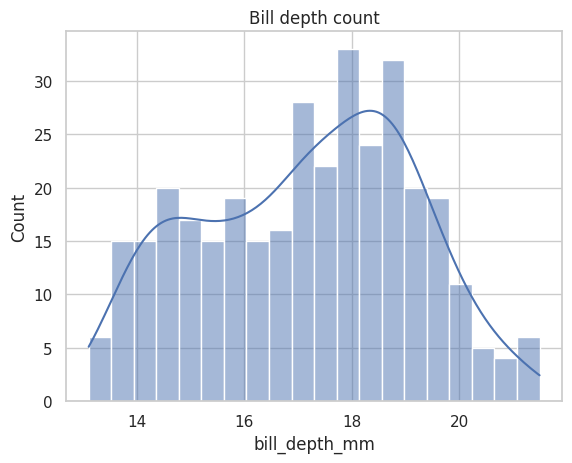

In [74]:
# let's look at bill_depth_mm histogram with seaborn first for all
# plt.figure(figsize=(7, 4))
sns.histplot(data=penguins_clean, x="bill_depth_mm", bins=20, kde=True)
# title
plt.title("Bill depth count")

Text(0.5, 1.0, 'Bill depth count colored by species')

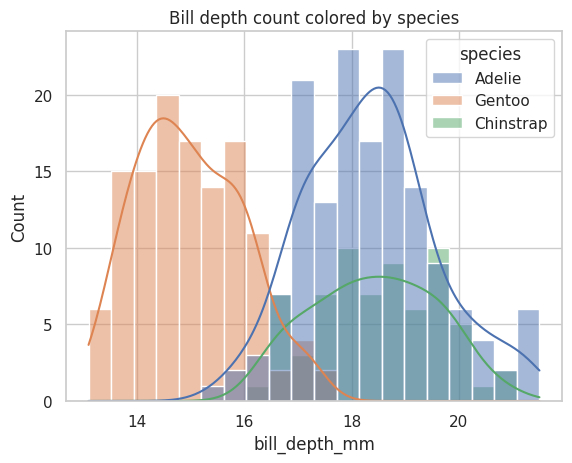

In [75]:
# now let's look at bill_depth_mm histogram with seaborn colored by species
sns.histplot(data=penguins_clean, x="bill_depth_mm", hue="species", bins=20, kde=True)
# title
plt.title("Bill depth count colored by species")

In [77]:
# let's take a look at our clean penguins again sample
penguins_clean.sample(7, random_state=2026) # same sample always

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
45,Adelie,Dream,39.6,18.8,190.0,4600.0,male,2007
84,Adelie,Dream,37.3,17.8,191.0,3350.0,female,2008
75,Adelie,Torgersen,42.8,18.5,195.0,4250.0,male,2008
310,Chinstrap,Dream,49.7,18.6,195.0,3600.0,male,2008
226,Gentoo,Biscoe,46.4,15.0,216.0,4700.0,female,2008
91,Adelie,Dream,41.1,18.1,205.0,4300.0,male,2008
163,Gentoo,Biscoe,49.0,16.1,216.0,5550.0,male,2007


Text(0.5, 1.0, 'Body mass count colored by sex')

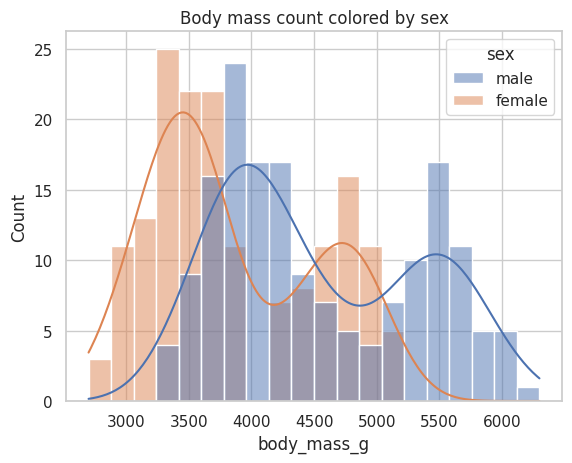

In [78]:
# TODO create histogram of penguin weights by sex
# let's use seaborn again
sns.histplot(data=penguins_clean, x="body_mass_g", hue="sex", bins=20, kde=True)
# title
plt.title("Body mass count colored by sex")

In [80]:
penguins_clean["sex"].value_counts()

,count
sex,
male,168
female,165


In [85]:
# let's create two histogram plots of body_mass_g by sex,
# and each plot would be colored by species
males = penguins_clean[penguins_clean["sex"] == "male"]
females = penguins_clean[penguins_clean["sex"] == "female"]
# let's print lengths
print("Number of males:", len(males))
print("Number of females:", len(females))
# total lengths
print("Total number of penguins:", len(penguins_clean))
# total number of unidentified penguins
print("Total number of unidentified penguins:", len(penguins_clean)-len(males)-len(females))
# print number of non existing values in sex column
print("Number of non existing values in sex column:", penguins_clean["sex"].isna().sum())
# here would be a good idea to insert assertion that males + females == total penguins_clean
assert len(males)+len(females)+penguins_clean["sex"].isna().sum() == len(penguins_clean), "You have unidentified genders in your dataset!"
# your assertion would depend on what you are trying to prevent
# here we have deemed, non identified penguins are fine, but unknown genders are not...
print("We have separated datesets by gender")


Number of males: 168
Number of females: 165
Total number of penguins: 342
Total number of unidentified penguins: 9
Number of non existing values in sex column: 9
We have separated datesets by gender


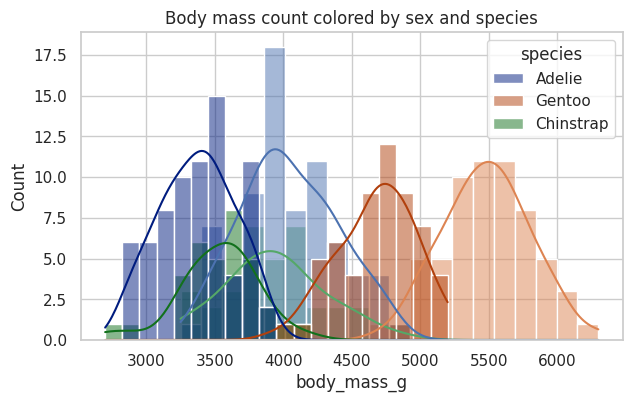

In [88]:
# now let's create two histograms for males and females colored by species in same plot
plt.figure(figsize=(7, 4))
sns.histplot(data=males, x="body_mass_g", hue="species", bins=20, kde=True)
# let's use a different color scale for females
sns.histplot(data=females, x="body_mass_g", hue="species", bins=20, kde=True, palette="dark")
# title
plt.title("Body mass count colored by sex and species")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

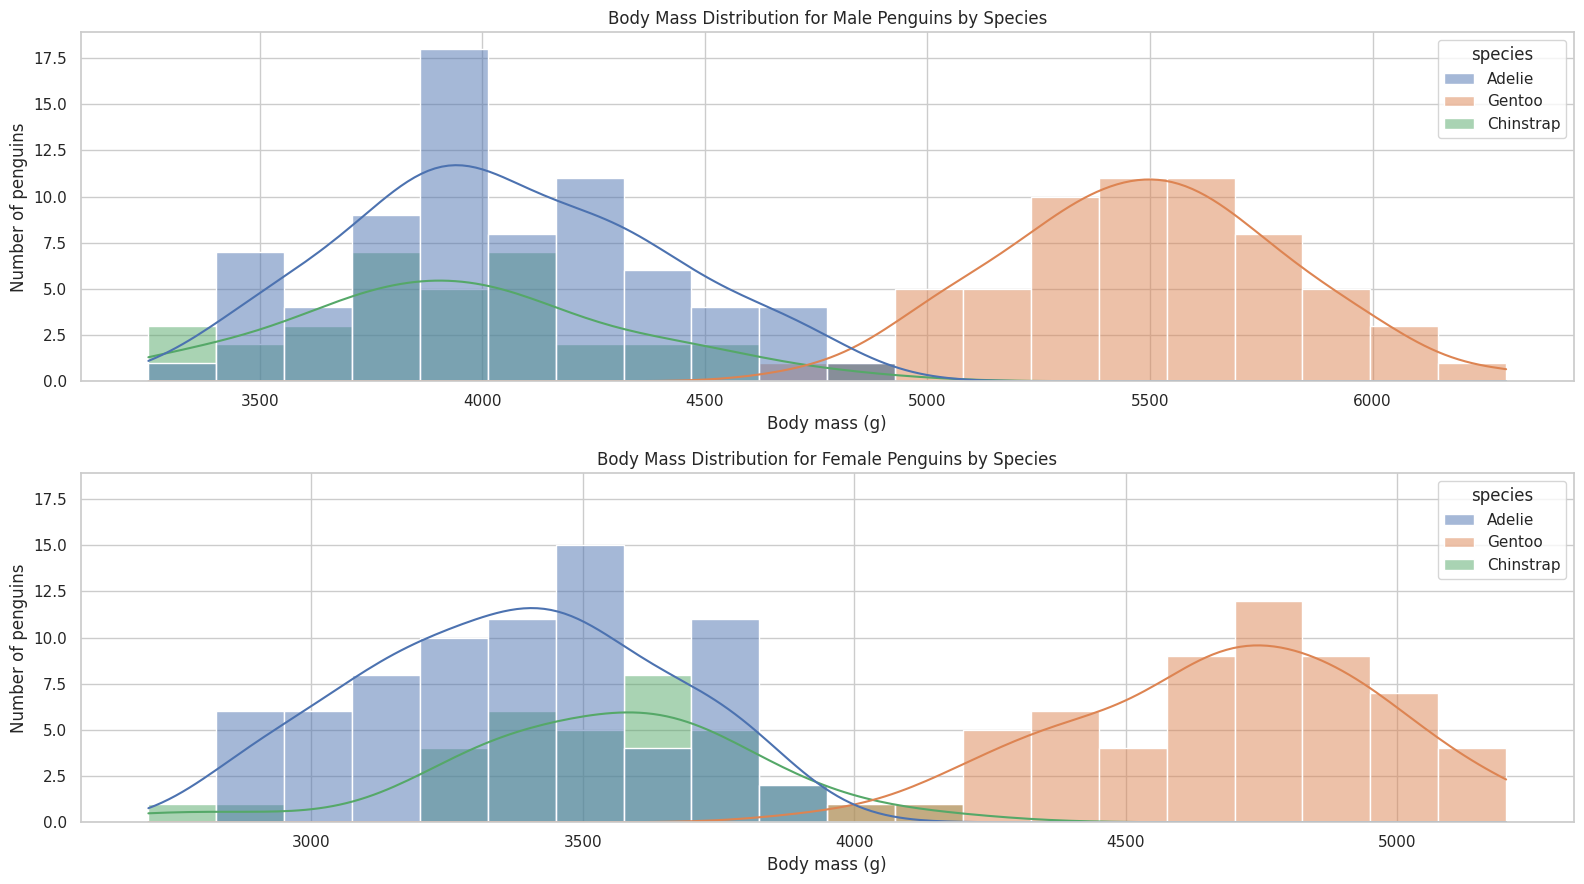

In [93]:
# let's create these histograms of males and females as separate plots in same cell
# again each plot should be colored by species
# so we need separate subfigures

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharey=True)
# here figsize=(16, 7) referes to whole picture

# Male penguins histogram
sns.histplot(data=males, x="body_mass_g", hue="species", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Body Mass Distribution for Male Penguins by Species")
axes[0].set_xlabel("Body mass (g)")
axes[0].set_ylabel("Number of penguins")

# Female penguins histogram
sns.histplot(data=females, x="body_mass_g", hue="species", bins=20, kde=True, ax=axes[1])
axes[1].set_title("Body Mass Distribution for Female Penguins by Species")
axes[1].set_xlabel("Body mass (g)")
axes[1].set_ylabel("Number of penguins") # Already shared y-axis, but good for clarity

plt.tight_layout()
# again I can save and download this
plt.savefig("body_mass_hist_by_sex.png")
# i already imported files function from  google.colab
files.download("body_mass_hist_by_sex.png")
plt.show()

### Instructor Demonstration: Scatter Plot

A scatter plot compares two numeric measurements. Each dot represents one penguin.


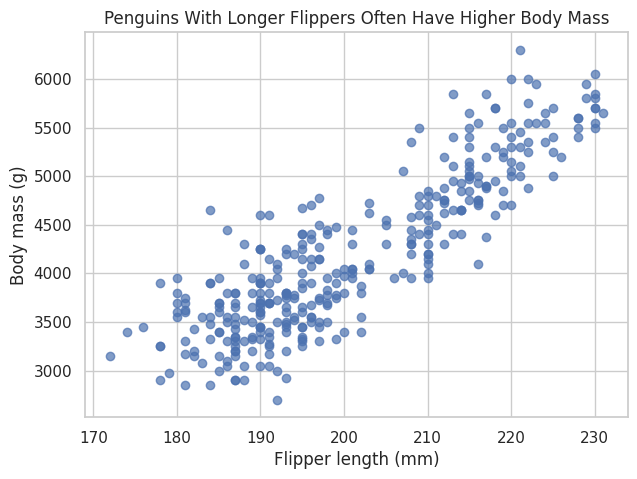

In [94]:
plt.figure(figsize=(7, 5))
plt.scatter(
    penguins_clean["flipper_length_mm"],
    penguins_clean["body_mass_g"],
    alpha=0.7
)
plt.title("Penguins With Longer Flippers Often Have Higher Body Mass")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.show()


In [95]:
# let's calculate the actual correlation for flipper_length_mm versus body_mass_g
corr = penguins_clean["flipper_length_mm"].corr(penguins_clean["body_mass_g"])
print("Correlation between flipper_length_mm and body_mass_g:", corr)
#


Correlation between flipper_length_mm and body_mass_g: 0.8712017673060114


Important wording:

- It is fine to say the chart shows a relationship or pattern.
- It is too strong to say flipper length causes body mass to increase.

Charts are evidence for patterns, not automatic proof of cause and effect.


### Guided Practice

The next scatter plot uses two bill measurements.

Run it once, then try changing the title.


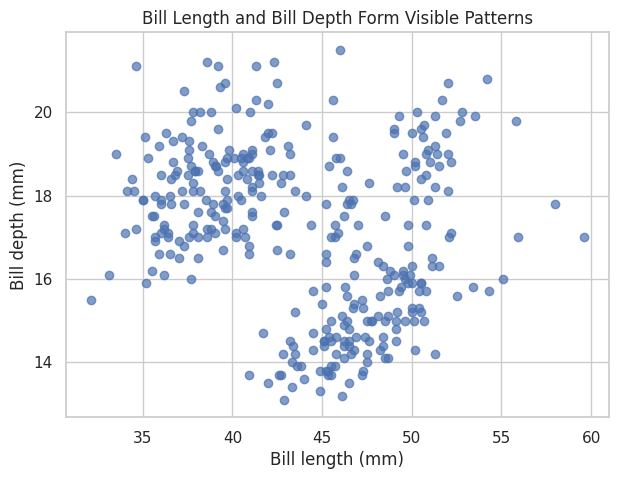

In [96]:
plt.figure(figsize=(7, 5))
plt.scatter(
    penguins_clean["bill_length_mm"],
    penguins_clean["bill_depth_mm"],
    alpha=0.7
)
plt.title("Bill Length and Bill Depth Form Visible Patterns")
plt.xlabel("Bill length (mm)")
plt.ylabel("Bill depth (mm)")
plt.show()


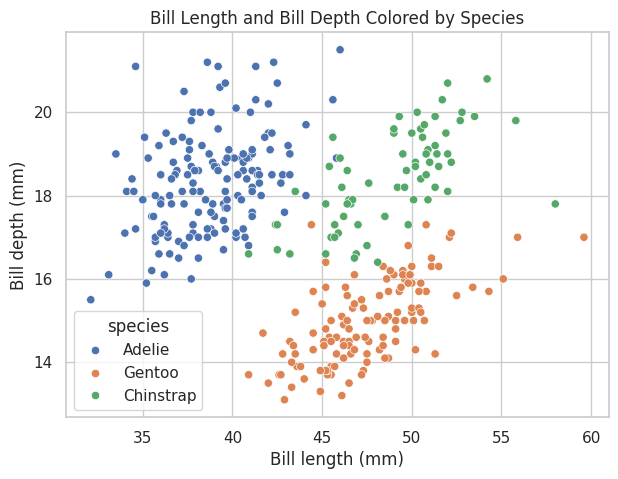

In [98]:
# let's colore scatter plot of     penguins_clean["bill_length_mm"],
# penguins_clean["bill_depth_mm"], by species
# let's use seaborn
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species"
)
plt.title("Bill Length and Bill Depth Colored by Species")
plt.xlabel("Bill length (mm)")
plt.ylabel("Bill depth (mm)")
plt.show()

### Check Your Understanding

1. What does each dot represent in a scatter plot?
2. What does `figsize` change?
3. What changes when you increase or decrease `bins` in a histogram?
4. Why is `plt.show()` useful in teaching notebooks?


## Correlation matrixes and correlation visuals for ALL

In [100]:
# we can create correlation visualizations for ALL numeric value pairs
# first what numeric columns do we have?
numeric_columns = penguins_clean.select_dtypes(include=['number']).columns
# let's describe these columns again
penguins_clean[numeric_columns].describe() # here numeric_columns is redundant because by default ALl numeric are include
# but it would work with any columns


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029240
std,5.459584,1.974793,14.061714,801.954536,0.817168
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [101]:
# base idea that year here would not be important unless these are ALL same penguins :0
# value counts of year
penguins_clean["year"].value_counts()

,count
year,
2009,119
2008,114
2007,109


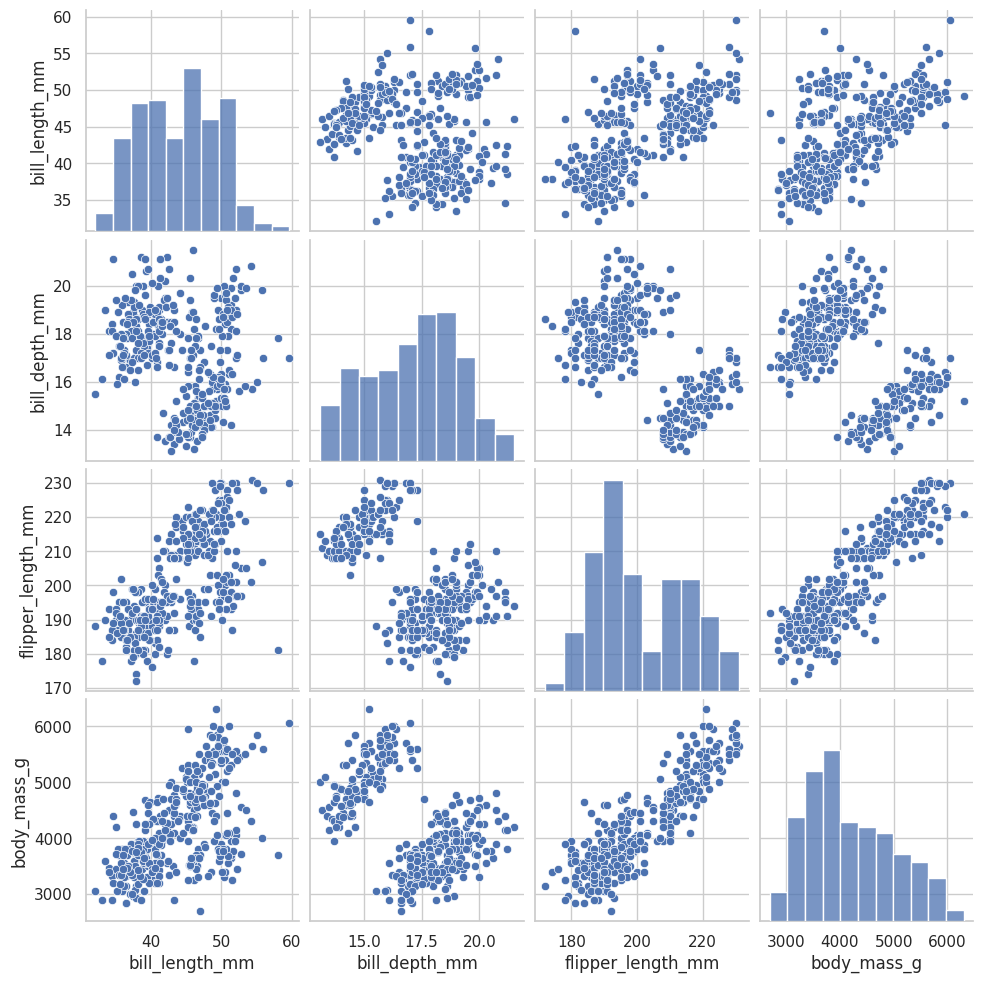

In [102]:
# so let's use seaborn pairplot to plot ALL numeric columns except year
# so let's first have view without year
penguins_without_year = penguins_clean.drop(columns=["year"])
# let's use seaborn pairplot
sns.pairplot(data=penguins_without_year) # so seaborn here will automatically use all numeric columns
# versus each other

#

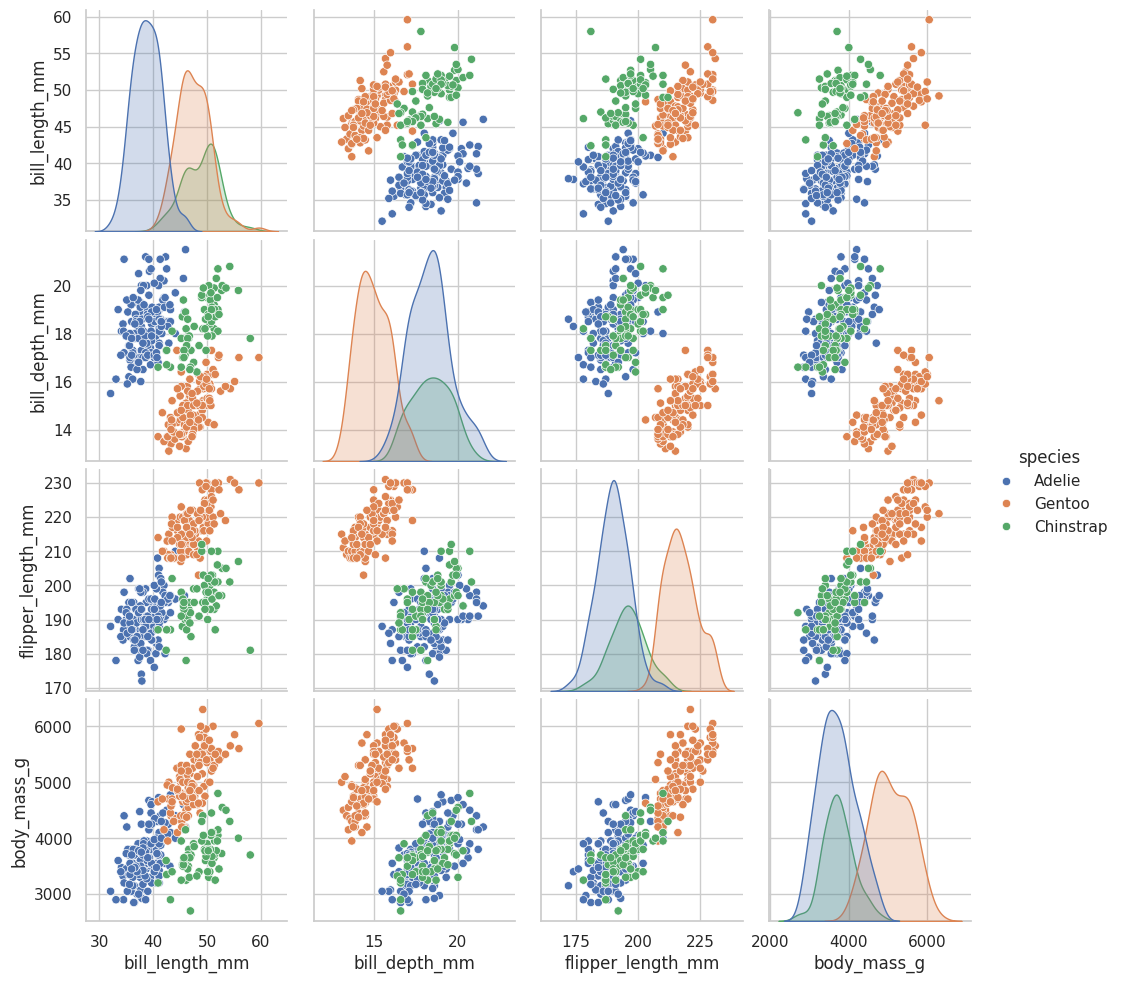

In [103]:
# let's add hue of species to the pairplot
sns.pairplot(data=penguins_without_year, hue="species") # so seaborn here will automatically use all numeric columns
# versus each other
#

## Correlation matrix

In [104]:
# pandas offers us a correlation matrix of all numeric columns
corr_matrix = penguins_clean[numeric_columns].corr()
corr_matrix

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000000,-0.235053,0.656181,0.595110,0.054545
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916,-0.060354
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202,0.169675
body_mass_g,0.595110,-0.471916,0.871202,1.000000,0.042209
year,0.054545,-0.060354,0.169675,0.042209,1.000000


In [106]:
# let's use penguins_without_year for corr_matrix
# we need to select numeric columns on the fly
corr_matrix = penguins_without_year.select_dtypes(include=['number']).corr()
corr_matrix

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


<Axes: >

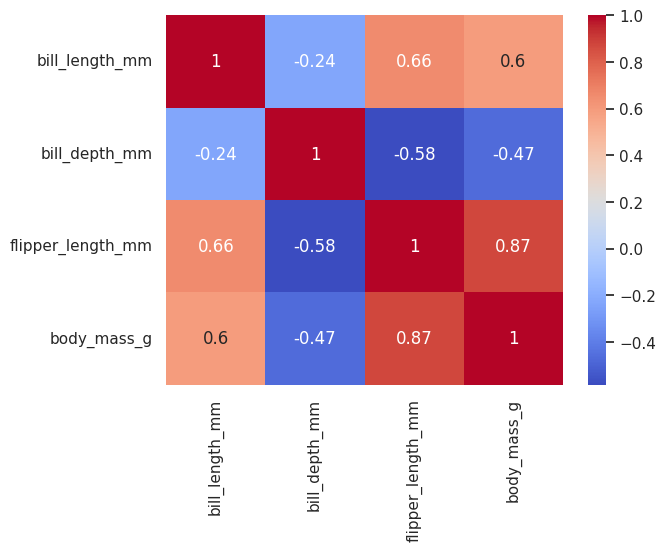

In [107]:
# let's use seaborn to create heatmap of our corr_matrix
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")


### Independent Mini Task

Create a Matplotlib histogram of `bill_depth_mm`. The working version is below.

Write one sentence below the chart about what you notice.


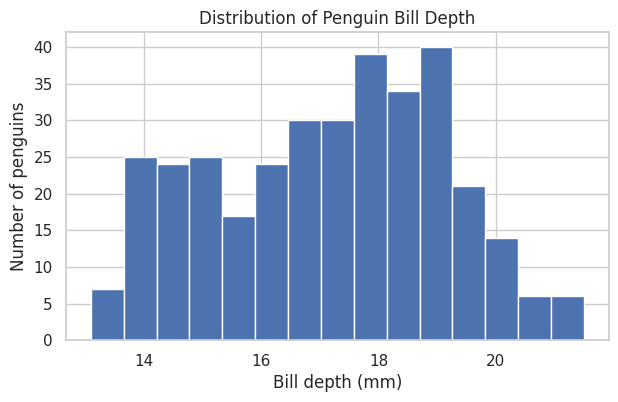

In [108]:
plt.figure(figsize=(7, 4))
plt.hist(penguins_clean["bill_depth_mm"], bins=15)
plt.title("Distribution of Penguin Bill Depth")
plt.xlabel("Bill depth (mm)")
plt.ylabel("Number of penguins")
plt.show()


### Common Mistakes

- Forgetting quotation marks around column names.
- Misspelling a column name.
- Using a categorical column in a histogram.
- Forgetting labels, which makes the chart harder to interpret later.


### Interpretation

Matplotlib gives us direct control over basic charts. It is useful for learning the building blocks of visualization.

Next, Seaborn will make grouped charts easier.


## Subchapter 4: Seaborn for Clearer Group Comparisons

### Goal

Seaborn works well with Pandas DataFrames. It is especially helpful when we want to compare groups.

We will use Seaborn to answer questions such as:

- How many penguins are in each species?
- Which species tends to have higher body mass?
- How do distributions differ by species?
- Do scatter plot patterns differ by species?


### Instructor Demonstration: Count Plot

Seaborn can count categories directly from the DataFrame.


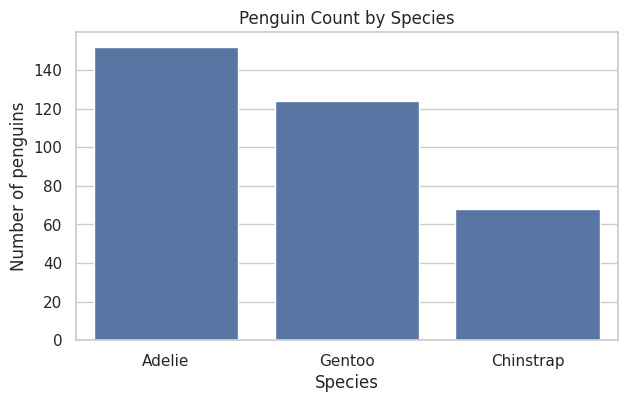

In [109]:
plt.figure(figsize=(7, 4))
sns.countplot(data=penguins, x="species", order=species_counts["species"])
plt.title("Penguin Count by Species")
plt.xlabel("Species")
plt.ylabel("Number of penguins")
plt.show()


### Instructor Demonstration: Summary Table Before a Group Chart

Before making a group comparison chart, it is often useful to make a summary table.

This is similar to a Pivot Table in Excel.


In [110]:
body_mass_summary = (
    penguins_clean
    .groupby("species")["body_mass_g"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
)

body_mass_summary


,count,mean,median,min,max
species,,,,,
Adelie,151,3700.7,3700.0,2850.0,4775.0
Chinstrap,68,3733.1,3700.0,2700.0,4800.0
Gentoo,123,5076.0,5000.0,3950.0,6300.0


### Instructor Demonstration: Bar Plot of Group Averages

A bar plot of averages can compare group centers. It is easy to read, but it does not show the full spread of values.


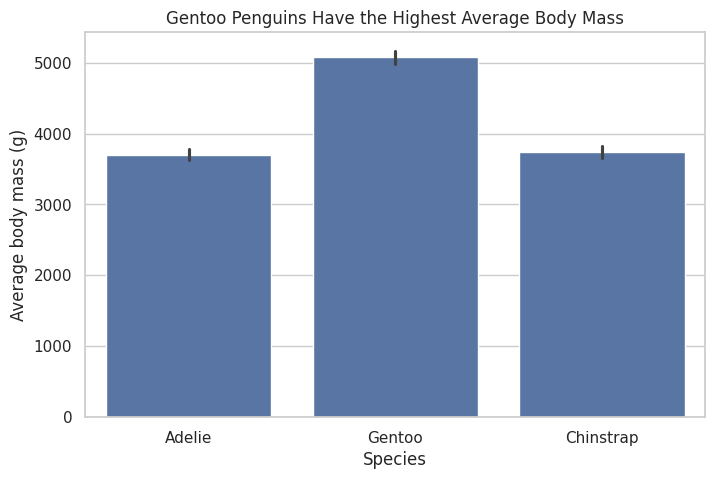

In [111]:
plt.figure(figsize=(8, 5))
sns.barplot(data=penguins_clean, x="species", y="body_mass_g")
plt.title("Gentoo Penguins Have the Highest Average Body Mass")
plt.xlabel("Species")
plt.ylabel("Average body mass (g)")
plt.show()


### Instructor Demonstration: Box Plot

A box plot shows more information than a simple average:

- the middle value
- the spread of typical values
- possible unusually high or low values

For beginners, read it as a compact comparison of center and spread.


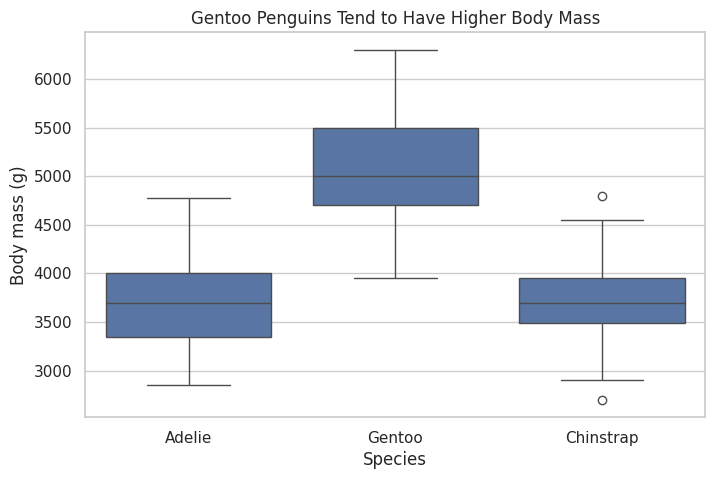

In [112]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=penguins_clean, x="species", y="body_mass_g")
plt.title("Gentoo Penguins Tend to Have Higher Body Mass")
plt.xlabel("Species")
plt.ylabel("Body mass (g)")
plt.show()


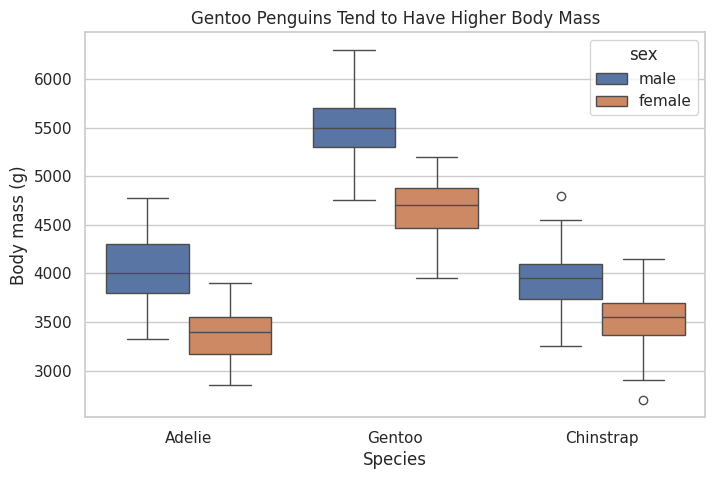

In [113]:
# now let's create a box plot with hue of gender
plt.figure(figsize=(8, 5))
sns.boxplot(data=penguins_clean, x="species", y="body_mass_g", hue="sex")
plt.title("Gentoo Penguins Tend to Have Higher Body Mass")
plt.xlabel("Species")
plt.ylabel("Body mass (g)")
plt.show()

### Instructor Demonstration: Histogram with Group Color

Color can help when it represents a meaningful group. Here, color represents species.


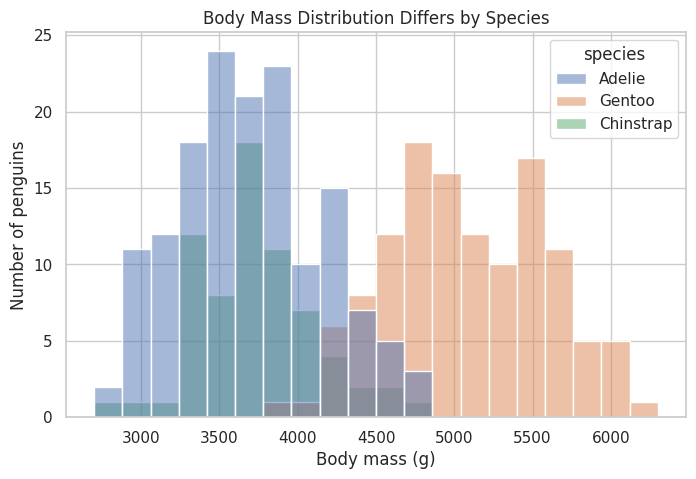

In [114]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=penguins_clean,
    x="body_mass_g",
    hue="species",
    bins=20
)
plt.title("Body Mass Distribution Differs by Species")
plt.xlabel("Body mass (g)")
plt.ylabel("Number of penguins")
plt.show()


### Instructor Demonstration: Scatter Plot with Group Color

This scatter plot uses color to show species. This makes the group patterns easier to see.


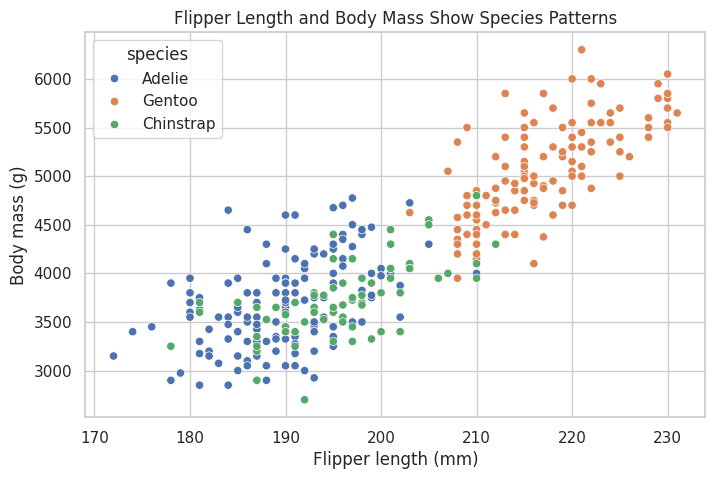

In [115]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=penguins_clean,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species"
)
plt.title("Flipper Length and Body Mass Show Species Patterns")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.show()


### Guided Practice

Change the measurement from body mass to bill length.

The code below already works. After running it once, try changing `bill_length_mm` to `flipper_length_mm`.


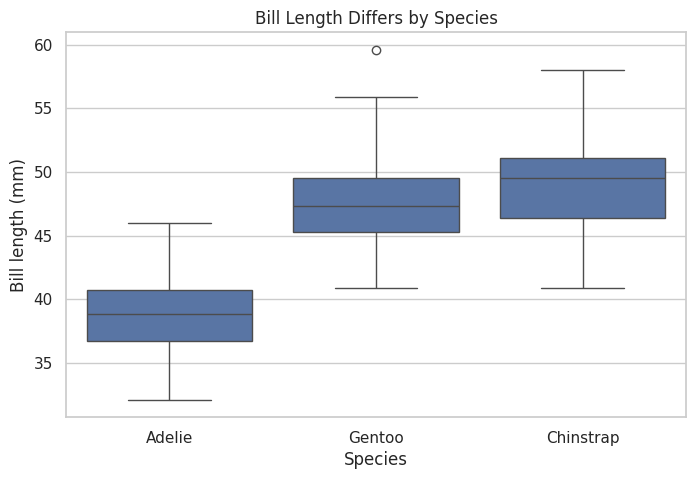

In [116]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=penguins_clean, x="species", y="bill_length_mm")
plt.title("Bill Length Differs by Species")
plt.xlabel("Species")
plt.ylabel("Bill length (mm)")
plt.show()


Sometimes we want to color by another category, such as `sex`.

Because `sex` has missing values, we make a version of the data with missing `sex` removed for this chart.


In [118]:
penguins_with_sex = penguins_clean.dropna(subset=["sex"]).copy() # here we drop rows where no gender is known

print("Rows with complete measurements and known sex:", len(penguins_with_sex))


Rows with complete measurements and known sex: 333


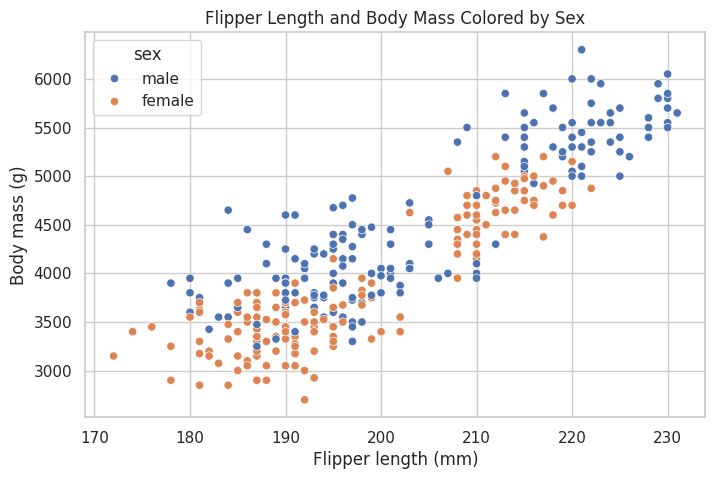

In [119]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=penguins_with_sex,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="sex"
)
plt.title("Flipper Length and Body Mass Colored by Sex")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.show()


### Check Your Understanding

1. Which species has the highest typical body mass?
2. What does a box plot help us see that a bar chart of averages does not?
3. Why is `hue="species"` useful in a scatter plot?
4. Why did we create `penguins_with_sex` before using `sex` in a chart?


### Independent Mini Task

Create a Seaborn chart comparing `flipper_length_mm` by `species`.

The working version is below. Write one observation after the chart.


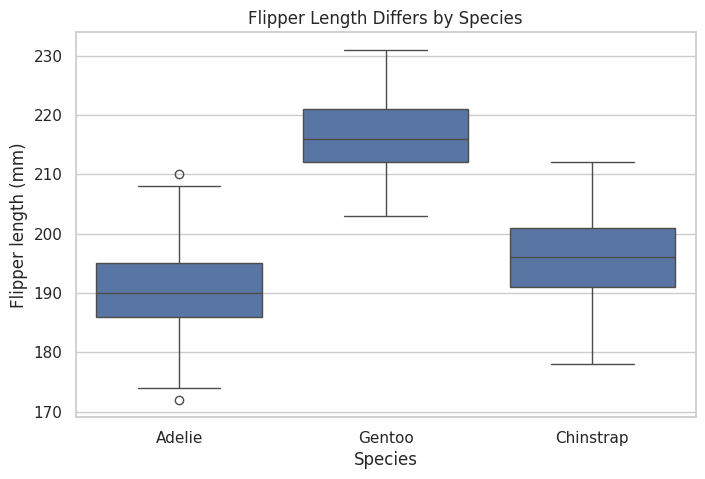

In [120]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=penguins_clean, x="species", y="flipper_length_mm")
plt.title("Flipper Length Differs by Species")
plt.xlabel("Species")
plt.ylabel("Flipper length (mm)")
plt.show()


### Common Mistakes

- Using too many colors at once.
- Treating a visual pattern as proof of cause and effect.
- Forgetting that a chart may hide missing values.
- Comparing groups without checking how many rows are in each group.


### Interpretation

Seaborn is useful when the question involves groups.

In this dataset, species differences are visible in body mass, flipper length, and bill measurements. These charts help us describe patterns, but they do not explain every biological reason behind the patterns.


In [121]:
# let's calculate average weights grouped by year and species
weights_by_year = penguins_clean.groupby(["year", "species"])["body_mass_g"].mean().reset_index()
weights_by_year

,year,species,body_mass_g
0,2007,Adelie,3696.428571
1,2007,Chinstrap,3694.230769
2,2007,Gentoo,5070.588235
3,2008,Adelie,3742.000000
4,2008,Chinstrap,3800.000000
5,2008,Gentoo,5019.565217
6,2009,Adelie,3664.903846
7,2009,Chinstrap,3725.000000
8,2009,Gentoo,5140.697674


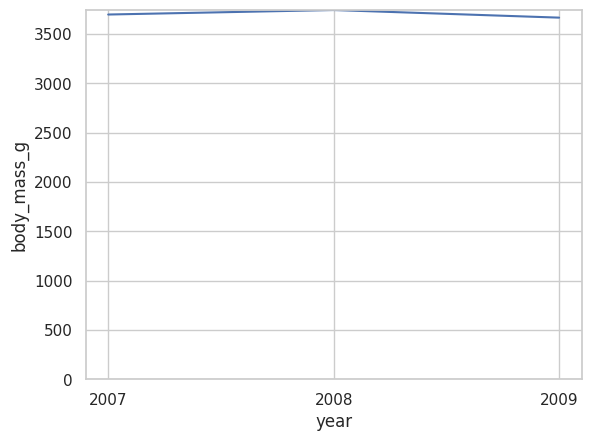

In [124]:
# let's plot just Adelie as line plot over the years
sns.lineplot(data=weights_by_year[weights_by_year["species"]=="Adelie"], x="year", y="body_mass_g")
# we only want x values be integers here 2007, 2008 and 2009
plt.xticks([2007, 2008, 2009])
# we want y values to start at 0
plt.ylim(bottom=0)

plt.show()

([<matplotlib.axis.XTick at 0x7983306792e0>,
 [Text(2007, 0, '2007'), Text(2008, 0, '2008'), Text(2009, 0, '2009')])

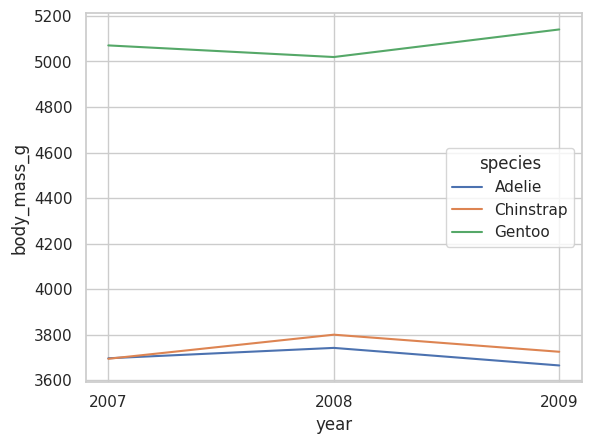

In [126]:
# let's plot all 3 species in one plot
sns.lineplot(data=weights_by_year, x="year", y="body_mass_g", hue="species")
# we could again add plt.ylim(bottom=0)
# or we could note that our bottom is not 0 - important to note this
# let's use year column to set automatic tick values to integers from min until mazx of year included
plt.xticks(range(min(weights_by_year["year"]), max(weights_by_year["year"])+1))
# range is number generator from start, until end (not included)
# so range(1,10) would give us 1 to 9 (not 10!!)
#

## Subchapter 5: Plotly for Interactive Exploration

### Goal

Plotly creates interactive charts. In Google Colab, these charts can be useful because you can hover over points and inspect details.

Use Plotly when interaction helps exploration. Still write clear titles, labels, and interpretations.


### Instructor Demonstration: Interactive Scatter Plot

This chart compares flipper length and body mass. Hover over a point to see more details.


In [127]:
if PLOTLY_AVAILABLE:
    fig = px.scatter(
        penguins_clean,
        x="flipper_length_mm",
        y="body_mass_g",
        color="species",
        hover_data=["island", "sex", "year"],
        title="Interactive View: Flipper Length and Body Mass by Species",
        labels={
            "flipper_length_mm": "Flipper length (mm)",
            "body_mass_g": "Body mass (g)",
            "species": "Species",
            "island": "Island",
            "sex": "Sex",
            "year": "Year",
        },
    )
    fig.show()
else:
    print("Plotly is not available here. In Google Colab, run this cell to see the interactive scatter plot.")


In [128]:
# let's create the same plot but use differnt markers for males and females in sex column
# we know we have plotly no point in checking here
# fig is just a variable name, could use anything just like any regular variable
fig = px.scatter(
    penguins_clean,
    x="flipper_length_mm",
    y="body_mass_g",
    color="species",
    hover_data=["island", "sex", "year"],
    title="Interactive View: Flipper Length and Body Mass by Species",
    labels={
        "flipper_length_mm": "Flipper length (mm)",
        "body_mass_g": "Body mass (g)",
        "species": "Species",
        "island": "Island",
        "sex": "Sex",
        "year": "Year",
    },
    # let's use different markers for males and females in sex column
    symbol="sex",
)
# now we show the figure
fig.show()

In [129]:
penguins_clean.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029240
std,5.459584,1.974793,14.061714,801.954536,0.817168
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [130]:
penguins_clean.describe(include="O")

,species,island,sex
count,342,342,333
unique,3,3,2
top,Adelie,Biscoe,male
freq,151,167,168


In [133]:
# let's go for 5 dimensional scatter plot
# we plot flipper_length_mm versus bill_length_mm
# we use color for species
# marker for sex
# size for bill_length_mm
fig = px.scatter(
    penguins_clean,
    x="flipper_length_mm",
    y="bill_length_mm",
    color="species",
    hover_data=["island", "sex", "year","body_mass_g"],
    title="Interactive View: Flipper Length and Body Mass by Species",
    labels={
        "flipper_length_mm": "Flipper length (mm)",
        "body_mass_g": "Body mass (g)",
        "species": "Species",
        "island": "Island",
        "sex": "Sex",
        "year": "Year",
    },
    # let's use different markers for males and females in sex column
    # symbol="sex",
    size="bill_length_mm",
)
# now we show the figure
fig.show()


### Instructor Demonstration: Interactive Box Plot

This is the Plotly version of a species comparison.


In [134]:
if PLOTLY_AVAILABLE:
    fig = px.box(
        penguins_clean,
        x="species",
        y="body_mass_g",
        color="species",
        title="Interactive Box Plot: Body Mass by Species",
        labels={
            "species": "Species",
            "body_mass_g": "Body mass (g)",
        },
    )
    fig.show()
else:
    print("Plotly is not available here. In Google Colab, run this cell to see the interactive box plot.")


### Instructor Demonstration: Interactive Histogram

Histograms can also be interactive. Hovering helps you inspect the counts in each range.


In [135]:
if PLOTLY_AVAILABLE:
    fig = px.histogram(
        penguins_clean,
        x="flipper_length_mm",
        color="species",
        nbins=20,
        title="Interactive Histogram: Flipper Length by Species",
        labels={
            "flipper_length_mm": "Flipper length (mm)",
            "species": "Species",
        },
    )
    fig.show()
else:
    print("Plotly is not available here. In Google Colab, run this cell to see the interactive histogram.")


### Guided Practice

The next Plotly chart colors points by island instead of species.

After running it, compare it with the species-colored version. Which color choice is more useful for the question?


In [136]:
if PLOTLY_AVAILABLE:
    fig = px.scatter(
        penguins_clean,
        x="bill_length_mm",
        y="bill_depth_mm",
        color="island",
        hover_data=["species", "sex", "year"],
        title="Interactive View: Bill Measurements Colored by Island",
        labels={
            "bill_length_mm": "Bill length (mm)",
            "bill_depth_mm": "Bill depth (mm)",
            "island": "Island",
        },
    )
    fig.show()
else:
    print("Plotly is not available here. In Google Colab, run this cell to compare bill measurements interactively.")


### Check Your Understanding

1. What extra information appears when you hover over a Plotly point?
2. When might an interactive chart be more useful than a static chart?
3. Why should an interactive chart still have a clear title?
4. What can become confusing if we use too many colors or hover fields?


### Independent Mini Task

Create one Plotly chart that helps compare species.

The working version below compares bill length by species. You can change the y-axis measurement after running it once.


In [137]:
if PLOTLY_AVAILABLE:
    fig = px.box(
        penguins_clean,
        x="species",
        y="bill_length_mm",
        color="species",
        title="Interactive Box Plot: Bill Length by Species",
        labels={
            "species": "Species",
            "bill_length_mm": "Bill length (mm)",
        },
    )
    fig.show()
else:
    print("Plotly is not available here. In Google Colab, run this cell to see the interactive species comparison.")


### Common Mistakes

- Thinking interaction replaces interpretation.
- Adding too many hover fields.
- Coloring by a variable that does not help answer the question.
- Forgetting that interactive charts may look different when exported or printed.


### Interpretation

Plotly is strongest for exploration. It lets us inspect individual points and compare groups interactively.

For final communication, we still need clear written findings.


In [138]:
# let's group by species, island, and sex and then have have full describe of
# bill_length_mm	bill_depth_mm	flipper_length_mm	body_mass_g columns
grouped_by_species_island_sex = penguins_clean.groupby(["species", "island", "sex"])[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].describe()
grouped_by_species_island_sex

bill_length_mm                                     \
                                    count       mean       std   min     25%   
species   island    sex                                                        
Adelie    Biscoe    female           22.0  37.359091  1.762212  34.5  35.750   
                    male             22.0  40.590909  2.006634  37.6  39.025   
          Dream     female           27.0  36.911111  2.089043  32.1  36.000   
                    male             28.0  40.071429  1.748196  36.3  39.150   
          Torgersen female           24.0  37.554167  2.207887  33.5  35.850   
                    male             23.0  40.586957  3.027496  34.6  38.850   
Chinstrap Dream     female           34.0  46.573529  3.108669  40.9  45.425   
                    male             34.0  51.094118  1.564558  48.5  50.050   
Gentoo    Biscoe    female           58.0  45.563793  2.051247  40.9  43.850   
                    male             61.0  49.473770  2.720594  44.4  48.100   

                                                bill_depth_mm             ...  \
                              50%     75%   max         count       mean  ...   
species   island    sex                                                   ...   
Adelie    Biscoe    female  37.75  38.475  40.5          22.0  17.704545  ...   
                    male    40.80  41.550  45.6          22.0  19.036364  ...   
          Dream     female  36.80  37.850  42.2          27.0  17.618519  ...   
                    male    40.25  41.100  44.1          28.0  18.839286  ...   
          Torgersen female  37.60  39.125  41.1          24.0  17.550000  ...   
                    male    41.10  42.650  46.0          23.0  19.391304  ...   
Chinstrap Dream     female  46.30  47.375  58.0          34.0  17.588235  ...   
                    male    50.95  51.975  55.8          34.0  19.252941  ...   
Gentoo    Biscoe    female  45.50  46.875  50.5          58.0  14.237931  ...   
                    male    49.50  50.500  59.6          61.0  15.718033  ...   

                           flipper_length_mm        body_mass_g               \
                                         75%    max       count         mean   
species   island    sex                                                        
Adelie    Biscoe    female            191.75  199.0        22.0  3369.318182   
                    male              194.75  203.0        22.0  4050.000000   
          Dream     female            191.00  202.0        27.0  3344.444444   
                    male              196.00  208.0        28.0  4045.535714   
          Torgersen female            191.00  196.0        24.0  3395.833333   
                    male              198.00  210.0        23.0  4034.782609   
Chinstrap Dream     female            195.75  202.0        34.0  3527.205882   
                    male              203.00  212.0        34.0  3938.970588   
Gentoo    Biscoe    female            215.00  222.0        58.0  4679.741379   
                    male              225.00  231.0        61.0  5484.836066   

                                                                          \
                                   std     min      25%     50%      75%   
species   island    sex                                                    
Adelie    Biscoe    female  343.470715  2850.0  3150.00  3375.0  3693.75   
                    male    355.567956  3550.0  3800.00  4000.0  4268.75   
          Dream     female  212.056475  2900.0  3212.50  3400.0  3487.50   
                    male    330.547636  3425.0  3875.00  3987.5  4300.00   
          Torgersen female  259.144356  2900.0  3200.00  3400.0  3606.25   
                    male    372.471714  3325.0  3787.50  4000.0  4275.00   
Chinstrap Dream     female  285.333912  2700.0  3362.50  3550.0  3693.75   
                    male    362.137550  3250.0  3731.25  3950.0  4100.00   
Gentoo    Biscoe    female  281.578294  3950.0  4462.50

In [139]:
# let's transpose grouped_species_island_sex
grouped_by_species_island_sex = grouped_by_species_island_sex.T
grouped_by_species_island_sex

species                       Adelie                                         \
island                        Biscoe                     Dream                
sex                           female         male       female         male   
bill_length_mm    count    22.000000    22.000000    27.000000    28.000000   
                  mean     37.359091    40.590909    36.911111    40.071429   
                  std       1.762212     2.006634     2.089043     1.748196   
                  min      34.500000    37.600000    32.100000    36.300000   
                  25%      35.750000    39.025000    36.000000    39.150000   
                  50%      37.750000    40.800000    36.800000    40.250000   
                  75%      38.475000    41.550000    37.850000    41.100000   
                  max      40.500000    45.600000    42.200000    44.100000   
bill_depth_mm     count    22.000000    22.000000    27.000000    28.000000   
                  mean     17.704545    19.036364    17.618519    18.839286   
                  std       1.091298     0.879689     0.897448     1.033276   
                  min      16.000000    17.200000    15.500000    17.000000   
                  25%      17.000000    18.600000    17.050000    18.100000   
                  50%      17.700000    18.900000    17.800000    18.650000   
                  75%      18.250000    19.500000    18.450000    19.275000   
                  max      20.700000    21.100000    19.300000    21.200000   
flipper_length_mm count    22.000000    22.000000    27.000000    28.000000   
                  mean    187.181818   190.409091   187.851852   191.928571   
                  std       6.744567     6.463517     5.510156     6.803749   
                  min     172.000000   180.000000   178.000000   178.000000   
                  25%     184.250000   185.750000   185.000000   188.500000   
                  50%     187.000000   191.000000   188.000000   190.500000   
                  75%     191.750000   194.750000   191.000000   196.000000   
                  max     199.000000   203.000000   202.000000   208.000000   
body_mass_g       count    22.000000    22.000000    27.000000    28.000000   
                  mean   3369.318182  4050.000000  3344.444444  4045.535714   
                  std     343.470715   355.567956   212.056475   330.547636   
                  min    2850.000000  3550.000000  2900.000000  3425.000000   
                  25%    3150.000000  3800.000000  3212.500000  3875.000000   
                  50%    3375.000000  4000.000000  3400.000000  3987.500000   
                  75%    3693.750000  4268.750000  3487.500000  4300.000000   
                  max    3900.000000  4775.000000  3700.000000  4650.000000   

species                                              Chinstrap               \
island                     Torgersen                     Dream                
sex                           female         male       female         male   
bill_length_mm    count    24.000000    23.000000    34.000000    34.000000   
                  mean     37.554167    40.586957    46.573529    51.094118   
                  std       2.207887     3.027496     3.108669     1.564558   
                  min      33.500000    34.600000    40.900000    48.500000   
                  25%      35.850000    38.850000    45.425000    50.050000   
                  50%      37.600000    41.100000    46.300000    50.950000   
                  75%      39.125000    42.650000    47.375000    51.975000   
                  max      41.100000    46.000000    58.000000    55.800000   
bill_depth_mm     count    24.000000    23.000000    34.000000    34.000000   
                  mean     17.550000    19.391304    17.588235    19.252941   
                  std       0.879723     1.082469     0.781128     0.761273   
                  min      15.900000    17.600000    16.400000    17.500000   
                  25%      17.000000    18.550000

## End-of-Day Mini Report

Now assemble a short visual story.

Example question:

> How do penguin body measurements differ by species?

The report below includes three charts and short findings. In your own version, you can change the measurements or rewrite the findings.


### Report Chart 1: Species Counts

Start with sample size. This helps readers understand how many observations are available for each group.


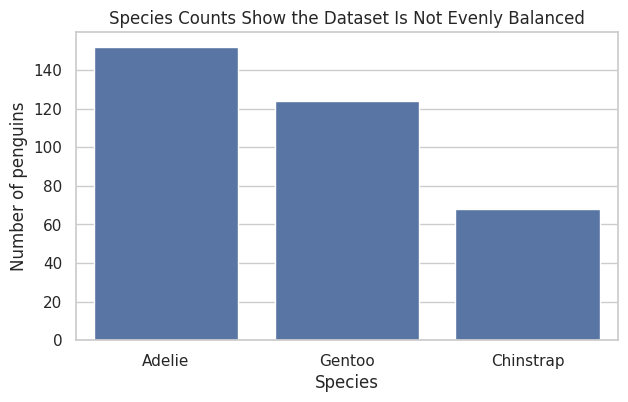

In [140]:
plt.figure(figsize=(7, 4))
sns.countplot(data=penguins, x="species", order=species_counts["species"])
plt.title("Species Counts Show the Dataset Is Not Evenly Balanced")
plt.xlabel("Species")
plt.ylabel("Number of penguins")
plt.show()


### Report Chart 2: Body Mass by Species

Next, compare a key measurement by species.


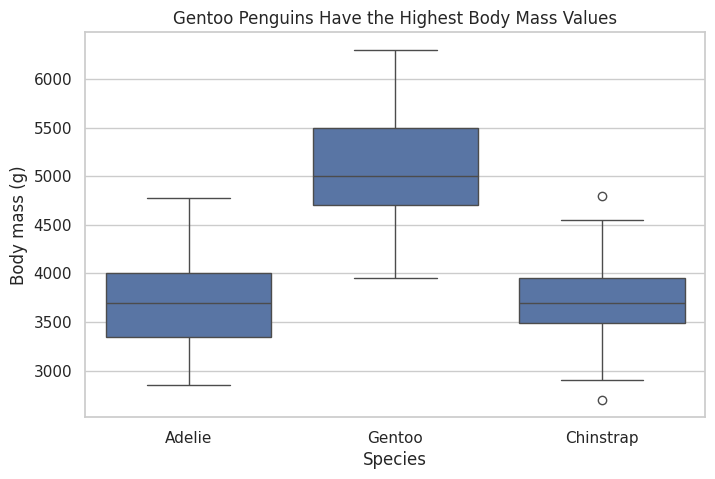

In [141]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=penguins_clean, x="species", y="body_mass_g")
plt.title("Gentoo Penguins Have the Highest Body Mass Values")
plt.xlabel("Species")
plt.ylabel("Body mass (g)")
plt.show()


### Report Chart 3: Relationship Between Flipper Length and Body Mass

Finally, use a scatter plot to show how two measurements relate to each other.


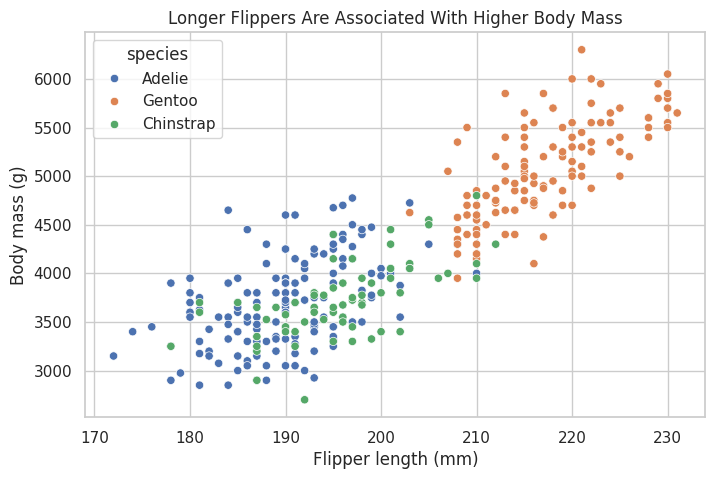

In [142]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=penguins_clean,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species"
)
plt.title("Longer Flippers Are Associated With Higher Body Mass")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.show()


### Supporting Summary Table

A table can support the chart story with exact values.


In [143]:
report_summary = (
    penguins_clean
    .groupby("species")
    .agg(
        penguins=("species", "count"),
        average_body_mass_g=("body_mass_g", "mean"),
        average_flipper_length_mm=("flipper_length_mm", "mean"),
        average_bill_length_mm=("bill_length_mm", "mean"),
    )
    .round(1)
)

report_summary


,penguins,average_body_mass_g,average_flipper_length_mm,average_bill_length_mm
species,,,,
Adelie,151,3700.7,190.0,38.8
Chinstrap,68,3733.1,195.8,48.8
Gentoo,123,5076.0,217.2,47.5


### Example Findings

- Adelie is the largest species group in this dataset, so group sizes are not equal.
- Gentoo penguins have the highest typical body mass.
- Gentoo penguins also tend to have longer flippers.
- Flipper length and body mass show a positive relationship: higher flipper length often appears with higher body mass.
- The charts show patterns, but they do not prove that one measurement causes another.


### Your Mini Report Task

Create your own short report by changing one part of the example:

- choose `bill_length_mm` instead of `body_mass_g`
- compare by `island` instead of `species`
- use one Plotly chart for interactive exploration
- rewrite the chart titles so they sound like findings

Your final report should include:

- 2 to 3 charts
- 3 to 5 written findings
- one caution about missing values, sample sizes, or overinterpreting charts


## Common Mistakes and Troubleshooting

Common beginner issues:

- Running cells out of order. If a variable is missing, run the setup and loading cells again.
- Misspelling column names. Use `penguins.columns` to check exact spelling.
- Forgetting quotation marks around column names, such as `"species"`.
- Using a histogram for category labels.
- Forgetting `plt.show()` after Matplotlib or Seaborn charts.
- Making a chart before checking missing values.
- Using too many colors, which makes the chart harder to read.
- Leaving titles as generic labels instead of useful descriptions.
- Interpreting a scatter plot as proof of cause and effect.

Debugging habit:

1. Read the error message.
2. Check the line number or the highlighted cell.
3. Check spelling and quotation marks.
4. Run the cells above the error.
5. Ask: "What object or column is Python looking for?"


## Reflection

Write short answers:

1. Which chart type felt most familiar from Excel?
2. Which chart type felt new?
3. What makes a chart easier to understand?
4. What is one pattern you noticed in the Penguins dataset?
5. What is one thing the charts cannot prove?
6. Which part of this workflow could be useful in your own work?


## Optional Bonus Tasks

Use these only if you have extra time:

1. Create a Plotly scatter plot with `facet_col="species"`.
2. Compare `bill_length_mm` and `bill_depth_mm` by species.
3. Save one Matplotlib chart as a PNG with `plt.savefig("penguins_chart.png", dpi=150)`.
4. Add a short Markdown caption under each chart.
5. Open the Gapminder bonus notebook and practice line charts for time trends.


## Run All Checklist

Before considering your notebook complete:

- The notebook runs from top to bottom.
- The Penguins dataset loads without manual upload.
- Missing values are checked before charting.
- Every chart has a clear title.
- Every chart has x-axis and y-axis labels.
- Color is used only when it helps interpretation.
- The final mini report includes 2 to 3 charts.
- The final mini report includes 3 to 5 written findings.
- At least one sentence avoids overclaiming what the charts prove.
